## Exercício proposto - Método Muskingum

O hidrograma de afluência até um trecho de rio é dado nas colunas 1 e 2 da Tabela abaixo.

|  (1) <br> Routing <br> period $\boldsymbol{j}$ <br> (h) | (2) <br> Inflow <br> $\boldsymbol{I}$ <br> (cfs) | |
| :---: | :---: | :---: |
| 1 | 93 |  |
| 2 | 137 |  |
| 3 | 208 |  |
| 4 | 320 |  |
| 5 | 442 |  |
| 6 | 546 |  |
| 7 | 630 |  |
| 8 | 678 |  |
| 9 | 691 |  |
| 10 | 675 |  |
| 11 | 634 |  |
| 12 | 571 |  |
| 13 | 477 |  |
| 14 | 390 |  |
| 15 | 329 |  |
| 16 | 247 |  |
| 17 | 184 |  |
| 18 | 134 |  |
| 19 | 108 |  |
| 20 | 90 |  |

Determine o hidrograma de saída deste trecho se K = 2,3 h, X = 0,15 e $\Delta t$= 1h. A vazão de saída inicial no tempo j = 1 é de 85 pés$^3$/s.

As equações do Método de Muskingum são:

$$
Q_{j+1}=C_1 I_{j+1}+C_2 I_j+C_3 Q_j
$$

sendo:
* $\displaystyle C_1  =\frac{\Delta t-2 K X}{2 K(1-X)+\Delta t}$
* $\displaystyle C_2  =\frac{\Delta t+2 K X}{2 K(1-X)+\Delta t} $
* $\displaystyle C_3  =\frac{2 K(1-X)-\Delta t}{2 K(1-X)+\Delta t}$

In [2]:
dt = 1 # h
K = 2.3 # h
X = 0.15 # h

In [3]:
C1 = (dt-2*K*X)/(2*K*(1-X)+dt)
C2 = (dt+2*K*X)/(2*K*(1-X)+dt)
C3 = (2*K*(1-X)-dt)/(2*K*(1-X)+dt)
C1, C2, C3

(0.06313645621181263, 0.3441955193482688, 0.5926680244399185)

In [4]:
C1+C2+C3

1.0

### Hidrograma afluente ou de entrada no rio:

In [5]:
!gdown 1xQyAatU4IYwHcqEByJm3XacE2_BiU-xr

Downloading...
From: https://drive.google.com/uc?id=1xQyAatU4IYwHcqEByJm3XacE2_BiU-xr
To: /content/exemplo_muskingum.csv
100% 166/166 [00:00<00:00, 529kB/s]


In [6]:
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
q_afluente = pd.read_csv('exemplo_muskingum.csv')
q_afluente

,T(h),Inflow(cfs),Unnamed: 2
0,1,93,NaN
1,2,137,NaN
2,3,208,NaN
3,4,320,NaN
4,5,442,NaN
5,6,546,NaN
6,7,630,NaN
7,8,678,NaN
8,9,691,NaN
9,10,675,NaN


In [8]:
# criando arrays
t = q_afluente['T(h)'].values
I = q_afluente['Inflow(cfs)'].values

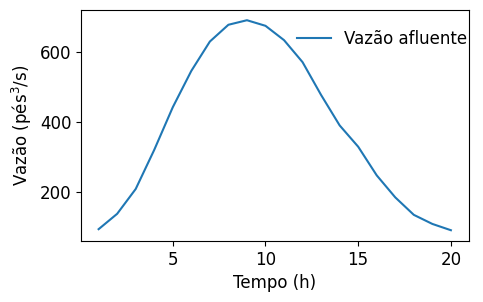

In [9]:
fig, ax = plt.subplots(figsize=(5,3))
ax.tick_params(axis='both', labelsize=12) #increase font size for ticks
plt.ylabel(r'Vazão (pés$^3$/s)', fontsize=12) #y label
plt.xlabel(r'Tempo (h)', fontsize=12) #y label
ax.plot(t,I, label='Vazão afluente')
ax.legend()
ax.legend(loc="upper right",bbox_to_anchor=(1.035, 0.98), frameon=False, fontsize=12)
plt.savefig('afluente.pdf', dpi = 300, bbox_inches='tight')
plt.show()

### Aplicando o método de Muskingum

In [10]:
q_muskingum = np.zeros(len(t))
q_muskingum[0] = 85 # cfs

$$
Q_{j+1}=C_1 I_{j+1}+C_2 I_j+C_3 Q_j
$$

In [11]:
for i in range(1,len(t)):
  q_muskingum[i] = C1*I[i]+C2*I[i-1]+C3*q_muskingum[i-1]

In [12]:
q_muskingum

array([ 85.        ,  91.03665988, 114.2416864 , 159.5037286 ,
       232.58163956, 324.45062548, 419.99823221, 508.56921705,
       578.40456652, 623.25810358, 641.74563776, 634.61299509,
       602.76656124, 546.0449477 , 478.63152705, 412.50463212,
       341.11170661, 273.95826196, 215.30723876, 170.46111299])

### Visualizando o resultado

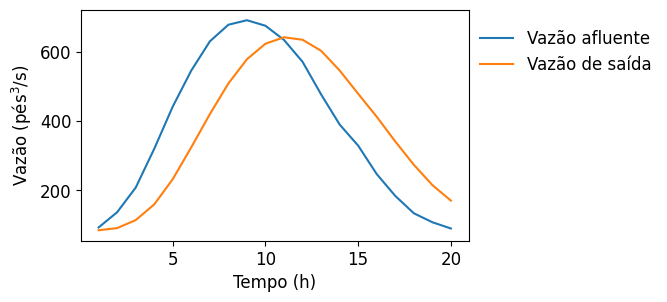

In [13]:
fig, ax = plt.subplots(figsize=(5,3))
ax.tick_params(axis='both', labelsize=12) #increase font size for ticks
plt.ylabel(r'Vazão (pés$^3$/s)', fontsize=12) #y label
plt.xlabel(r'Tempo (h)', fontsize=12) #y label
ax.plot(t,I, label='Vazão afluente')
ax.plot(t,q_muskingum, label='Vazão de saída')
ax.legend()
#ax.legend(loc="best", frameon=False, fontsize=12)
ax.legend(loc="upper right",bbox_to_anchor=(1.51, 0.98), frameon=False, fontsize=12)
plt.savefig('afluente+efluente.pdf', dpi = 300, bbox_inches='tight')
plt.show()

### Critério de estabilidade

Limites dos parâmetros X e K, critério para estabilidade numérica do Método de Muskingum (Tucci, 1993):

$$
X \leq \frac{\Delta t}{2 \, K} \leq(1-X)
$$

In [14]:
X, dt/(2*K), (1-X)

(0.15, 0.2173913043478261, 0.85)